In [7]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver


In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [4]:
MAX_TOKENS = 150

In [10]:
def call_model(state: MessagesState):

    messages=trim_messages(
        state["messages"],
        max_tokens=MAX_TOKENS,
        strategy="last",
        token_counter=count_tokens_approximately
    )
    print('Current Token Count ->', count_tokens_approximately(messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

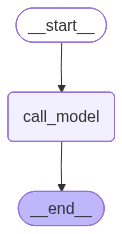

In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}
result=graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Subham."}]}, config)

result["messages"][-1].content

Current Token COunt -> 10
Hi! My name is Subham.


'Hello Subham! 👋 How can I help you today?'

In [11]:
result=graph.invoke({"messages": [{"role": "user", "content": "I'm learning LangGraph!"}]}, config)

result["messages"][-1].content

Current Token COunt -> 36
Hi! My name is Subham.
Hello Subham! 👋 How can I help you today?
I'm learning LangGraph!


'That’s awesome! LangGraph is a powerful framework for building conversational AI that can reason, remember, and orchestrate multiple tools or services. 🚀\n\n---\n\n## Quick Overview\n\n| Component | What it does | Typical use‑case |\n|-----------|--------------|-----------------|\n| **Node** | A single unit of logic (e.g., a prompt, a function call, a tool invocation). | Generate a response, call an API, parse data. |\n| **Edge** | Connects nodes, can be conditional or deterministic. | Route based on user intent, tool output, or state. |\n| **Graph** | The whole flow – a directed graph of nodes/edges. | The overall conversation logic. |\n| **State** | Stores context (messages, tool results, flags). | Keeps track of user goals, memory, etc. |\n| **Connector** | Bridges LangGraph to external services (LLMs, APIs, databases). | Call OpenAI, retrieve from a DB, etc. |\n| **Agent** | Orchestrates the graph, decides which node to run next. | The “brain” that drives the conversation. |\n\n--

In [12]:
result=graph.invoke({"messages": [{"role": "user", "content": "Can you explain short-term memory?"}]}, config)

result["messages"][-1].content

Current Token COunt -> 13
Can you explain short-term memory?


'**Short‑term memory (STM)** is the part of memory that holds information for a brief period (seconds to a minute or so) while you’re actively using it.  It’s the “working surface” on which we manipulate data, plan, and make decisions.\n\n---\n\n## 1. Core characteristics\n\n| Feature | What it means |\n|---------|---------------|\n| **Capacity** | Roughly 7\u202f±\u202f2 “chunks” (Miller, 1956).  A “chunk” can be a digit, a word, a picture, or a meaningful unit (e.g., a word or a phrase). |\n| **Duration** | 15–30\u202fseconds without rehearsal; up to a minute with active maintenance. |\n| **Encoding** | Primarily *phonological* (sound) and *visuospatial* (image) codes. |\n| **Decay vs. Interference** | Forgetting can be due to *decay* (time‑based loss) or *interference* (new information disrupting old). |\n| **Rehearsal** | *Maintenance rehearsal* (repeating the item) keeps it alive; *elaborative rehearsal* (linking to existing knowledge) transfers it to long‑term memory. |\n\n---\n\

In [13]:
result=graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

result["messages"][-1].content

Current Token COunt -> 8
What is my name?


'I’m not sure—could you let me know what you’d like me to call you?'